# 验证 plain

device: cuda
Epoch [1/30] Loss: 1.7779 Train Error: 66.44% Test Error: 60.38%
Epoch [2/30] Loss: 1.4222 Train Error: 52.43% Test Error: 48.06%
Epoch [3/30] Loss: 1.1510 Train Error: 41.86% Test Error: 49.19%
Epoch [4/30] Loss: 0.9625 Train Error: 34.31% Test Error: 41.85%
Epoch [5/30] Loss: 0.8180 Train Error: 28.38% Test Error: 29.87%
Epoch [6/30] Loss: 0.7014 Train Error: 24.20% Test Error: 34.60%
Epoch [7/30] Loss: 0.6300 Train Error: 21.69% Test Error: 23.40%
Epoch [8/30] Loss: 0.5836 Train Error: 20.07% Test Error: 22.68%
Epoch [9/30] Loss: 0.5402 Train Error: 18.49% Test Error: 31.10%
Epoch [10/30] Loss: 0.5120 Train Error: 17.38% Test Error: 22.53%
Epoch [11/30] Loss: 0.4800 Train Error: 16.39% Test Error: 23.86%
Epoch [12/30] Loss: 0.4515 Train Error: 15.51% Test Error: 22.83%
Epoch [13/30] Loss: 0.4374 Train Error: 14.95% Test Error: 17.71%
Epoch [14/30] Loss: 0.4163 Train Error: 14.29% Test Error: 19.91%
Epoch [15/30] Loss: 0.4102 Train Error: 13.97% Test Error: 15.66%
Epoch 

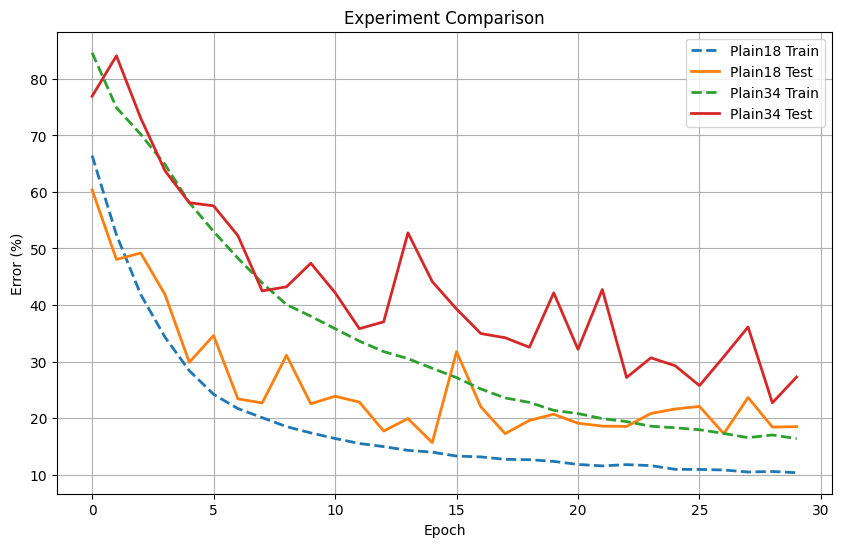

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

from models.nornet import PlainNet18 #模型加载
from models.nornet import PlainNet34

from utils.trainer import train_model  #训练代码
from utils.plot import plot_experiment #绘图代码

import config


# =========================
# device
# =========================

device = config.DEVICE

print('device:', device)

transform_train = transforms.Compose([

    transforms.RandomCrop(32, padding=4), #对图像高宽进行填充 32*32->40*40

    transforms.RandomHorizontalFlip(), #对图像随机翻转

    transforms.ToTensor(),

    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),#CIFAR103通道均值
        (0.2023, 0.1994, 0.2010) #CIFAR103通道标准差
    )
])


transform_test = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

# =========================
# dataset
# =========================

train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=False,
    transform=transform_train
)


test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=False,
    transform=transform_test
)


# =========================
# dataloader
# =========================

train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=2
)


test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=2
)
# =========================
# loss
# =========================

criterion = nn.CrossEntropyLoss()



history = {}

# Plain18
model = PlainNet18().to(device)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=config.LEARNING_RATE,
    momentum=config.MOMENTUM,
    weight_decay=config.WEIGHT_DECAY
)

history['Plain18'] = train_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    device,
    config.EPOCHS
)

# Plain34
model = PlainNet34().to(device)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=config.LEARNING_RATE,
    momentum=config.MOMENTUM,
    weight_decay=config.WEIGHT_DECAY
)

history['Plain34'] = train_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    device,
    config.EPOCHS
)

plot_experiment(
    history,
    './outputs/figures/plainnet_compare.png'
)



# 复现resnet

device: cuda
Epoch [1/30] Loss: 1.9582 Train Error: 68.35% Test Error: 59.98%
Epoch [2/30] Loss: 1.4706 Train Error: 54.17% Test Error: 48.17%
Epoch [3/30] Loss: 1.2211 Train Error: 44.17% Test Error: 42.83%
Epoch [4/30] Loss: 1.0364 Train Error: 37.18% Test Error: 33.70%
Epoch [5/30] Loss: 0.9020 Train Error: 32.08% Test Error: 30.58%
Epoch [6/30] Loss: 0.7896 Train Error: 27.95% Test Error: 32.13%
Epoch [7/30] Loss: 0.7088 Train Error: 24.91% Test Error: 24.82%
Epoch [8/30] Loss: 0.6202 Train Error: 21.76% Test Error: 26.28%
Epoch [9/30] Loss: 0.5569 Train Error: 19.38% Test Error: 20.75%
Epoch [10/30] Loss: 0.5087 Train Error: 17.65% Test Error: 20.37%
Epoch [11/30] Loss: 0.4689 Train Error: 16.24% Test Error: 22.98%
Epoch [12/30] Loss: 0.4382 Train Error: 15.14% Test Error: 18.20%
Epoch [13/30] Loss: 0.4168 Train Error: 14.41% Test Error: 16.08%
Epoch [14/30] Loss: 0.3890 Train Error: 13.27% Test Error: 15.86%
Epoch [15/30] Loss: 0.3710 Train Error: 12.83% Test Error: 17.09%
Epoch 

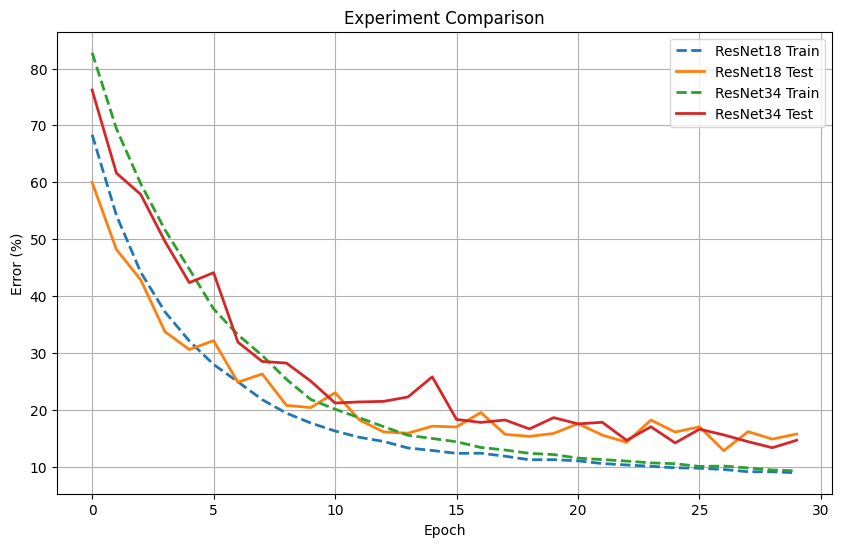

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

from models.resnet import ResNet18 #模型加载
from models.resnet import ResNet34

from utils.trainer import train_model  #训练代码
from utils.plot import plot_experiment #绘图代码

import config


# =========================
# device
# =========================

device = config.DEVICE

print('device:', device)

transform_train = transforms.Compose([

    transforms.RandomCrop(32, padding=4), #对图像高宽进行填充 32*32->40*40

    transforms.RandomHorizontalFlip(), #对图像随机翻转

    transforms.ToTensor(),

    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),#CIFAR103通道均值
        (0.2023, 0.1994, 0.2010) #CIFAR103通道标准差
    )
])


transform_test = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

# =========================
# dataset
# =========================

train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=False,
    transform=transform_train
)


test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=False,
    transform=transform_test
)


# =========================
# dataloader
# =========================

train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=2
)


test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=2
)
# =========================
# loss
# =========================

criterion = nn.CrossEntropyLoss()



history = {}

# ResNet18
model = ResNet18().to(device)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=config.LEARNING_RATE,
    momentum=config.MOMENTUM,
    weight_decay=config.WEIGHT_DECAY
)

history['ResNet18'] = train_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    device,
    config.EPOCHS
)

# ResNet34
model = ResNet34().to(device)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=config.LEARNING_RATE,
    momentum=config.MOMENTUM,
    weight_decay=config.WEIGHT_DECAY
)

history['ResNet34'] = train_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    device,
    config.EPOCHS
)

plot_experiment(
    history,
    './outputs/figures/resnet_compare.png'
)



# 加入SEBlock 之后的效果

device: cuda
Epoch [1/30] Loss: 1.5768 Train Error: 57.88% Test Error: 48.92%
Epoch [2/30] Loss: 1.0651 Train Error: 38.47% Test Error: 37.81%
Epoch [3/30] Loss: 0.8146 Train Error: 28.74% Test Error: 33.72%
Epoch [4/30] Loss: 0.6798 Train Error: 23.86% Test Error: 27.69%
Epoch [5/30] Loss: 0.5886 Train Error: 20.41% Test Error: 26.02%
Epoch [6/30] Loss: 0.5373 Train Error: 18.57% Test Error: 28.54%
Epoch [7/30] Loss: 0.4865 Train Error: 16.90% Test Error: 20.28%
Epoch [8/30] Loss: 0.4460 Train Error: 15.53% Test Error: 17.64%
Epoch [9/30] Loss: 0.4153 Train Error: 14.27% Test Error: 21.43%
Epoch [10/30] Loss: 0.3884 Train Error: 13.37% Test Error: 17.93%
Epoch [11/30] Loss: 0.3734 Train Error: 12.93% Test Error: 19.10%
Epoch [12/30] Loss: 0.3506 Train Error: 12.17% Test Error: 17.75%
Epoch [13/30] Loss: 0.3375 Train Error: 11.64% Test Error: 18.45%
Epoch [14/30] Loss: 0.3269 Train Error: 11.25% Test Error: 14.81%
Epoch [15/30] Loss: 0.3133 Train Error: 10.81% Test Error: 18.21%
Epoch 

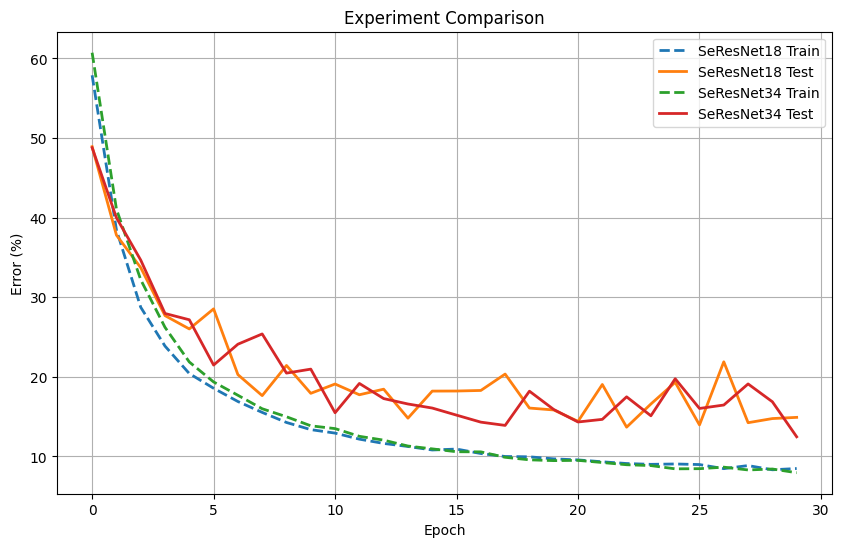

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

from models.SeResNetblock import SEResNet18 #模型加载
from models.SeResNetblock import SEResNet34

from utils.trainer import train_model  #训练代码
from utils.plot import plot_experiment #绘图代码

import config


# =========================
# device
# =========================

device = config.DEVICE

print('device:', device)

transform_train = transforms.Compose([

    transforms.RandomCrop(32, padding=4), #对图像高宽进行填充 32*32->40*40

    transforms.RandomHorizontalFlip(), #对图像随机翻转

    transforms.ToTensor(),

    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),#CIFAR103通道均值
        (0.2023, 0.1994, 0.2010) #CIFAR103通道标准差
    )
])


transform_test = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

# =========================
# dataset
# =========================

train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=False,
    transform=transform_train
)


test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=False,
    transform=transform_test
)


# =========================
# dataloader
# =========================

train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=2
)


test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=2
)
# =========================
# loss
# =========================

criterion = nn.CrossEntropyLoss()



history = {}

# SEResNet18
model = SEResNet18().to(device)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=config.LEARNING_RATE,
    momentum=config.MOMENTUM,
    weight_decay=config.WEIGHT_DECAY
)

history['SeResNet18'] = train_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    device,
    config.EPOCHS
)

# SEResNet34
model = SEResNet34().to(device)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=config.LEARNING_RATE,
    momentum=config.MOMENTUM,
    weight_decay=config.WEIGHT_DECAY
)

history['SeResNet34'] = train_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    device,
    config.EPOCHS
)

plot_experiment(
    history,
    './outputs/figures/SEresnet_compare.png'
)



# SEblock18 + dropout

device: cuda
Epoch [1/30] Loss: 1.6604 Train Error: 60.33% Test Error: 52.01%
Epoch [2/30] Loss: 1.1612 Train Error: 41.72% Test Error: 37.74%
Epoch [3/30] Loss: 0.9083 Train Error: 32.33% Test Error: 30.34%
Epoch [4/30] Loss: 0.7472 Train Error: 26.33% Test Error: 27.55%
Epoch [5/30] Loss: 0.6441 Train Error: 22.56% Test Error: 22.59%
Epoch [6/30] Loss: 0.5723 Train Error: 19.78% Test Error: 21.69%
Epoch [7/30] Loss: 0.5250 Train Error: 18.09% Test Error: 19.73%
Epoch [8/30] Loss: 0.4778 Train Error: 16.44% Test Error: 18.23%
Epoch [9/30] Loss: 0.4413 Train Error: 15.05% Test Error: 21.45%
Epoch [10/30] Loss: 0.4205 Train Error: 14.39% Test Error: 17.82%
Epoch [11/30] Loss: 0.3977 Train Error: 13.67% Test Error: 22.32%
Epoch [12/30] Loss: 0.3753 Train Error: 12.79% Test Error: 16.33%
Epoch [13/30] Loss: 0.3581 Train Error: 12.33% Test Error: 15.02%
Epoch [14/30] Loss: 0.3457 Train Error: 11.88% Test Error: 17.38%
Epoch [15/30] Loss: 0.3355 Train Error: 11.49% Test Error: 20.80%
Epoch 

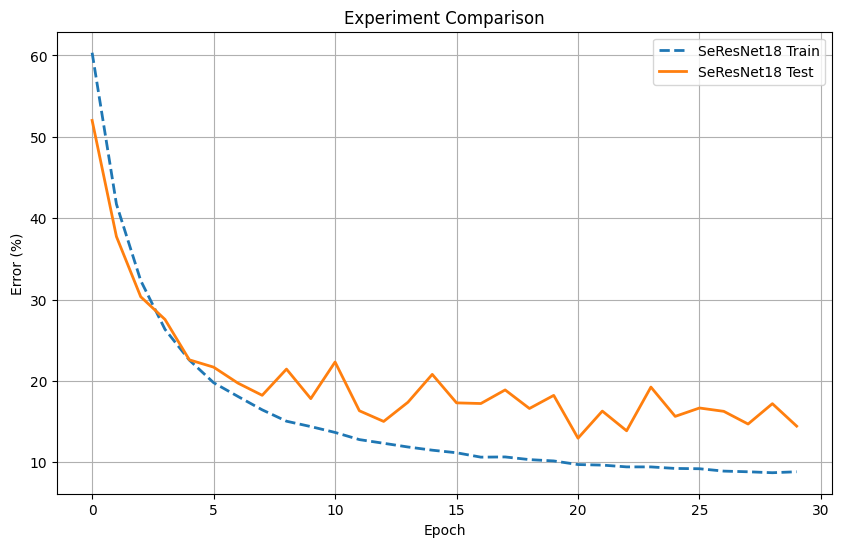

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

from models.SeResNetblock_dorpout import SEResNetDrop18 #模型加载

from utils.trainer import train_model  #训练代码
from utils.plot import plot_experiment #绘图代码

import config


# =========================
# device
# =========================

device = config.DEVICE

print('device:', device)

transform_train = transforms.Compose([

    transforms.RandomCrop(32, padding=4), #对图像高宽进行填充 32*32->40*40

    transforms.RandomHorizontalFlip(), #对图像随机翻转

    transforms.ToTensor(),

    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),#CIFAR103通道均值
        (0.2023, 0.1994, 0.2010) #CIFAR103通道标准差
    )
])


transform_test = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

# =========================
# dataset
# =========================

train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=False,
    transform=transform_train
)


test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=False,
    transform=transform_test
)


# =========================
# dataloader
# =========================

train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=2
)


test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=2
)
# =========================
# loss
# =========================

criterion = nn.CrossEntropyLoss()



history = {}

# SEResNet18
model = SEResNetDrop18().to(device)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=config.LEARNING_RATE,
    momentum=config.MOMENTUM,
    weight_decay=config.WEIGHT_DECAY
)

history['SeResNet18'] = train_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    device,
    config.EPOCHS
)


plot_experiment(
    history,
    './outputs/figures/SEResNetDrop18.png'
)



# SEblock18 + dropout+ sehodler

device: cuda
Epoch [1/30] LR: 0.099726 Loss: 1.7723 Train Error: 64.00% Test Error: 54.54%
Epoch [2/30] LR: 0.098907 Loss: 1.2247 Train Error: 44.27% Test Error: 46.26%
Epoch [3/30] LR: 0.097553 Loss: 0.9626 Train Error: 34.29% Test Error: 37.43%
Epoch [4/30] LR: 0.095677 Loss: 0.7917 Train Error: 28.05% Test Error: 31.64%
Epoch [5/30] LR: 0.093301 Loss: 0.6758 Train Error: 23.72% Test Error: 26.13%
Epoch [6/30] LR: 0.090451 Loss: 0.5886 Train Error: 20.25% Test Error: 23.30%
Epoch [7/30] LR: 0.087157 Loss: 0.5292 Train Error: 18.36% Test Error: 22.55%
Epoch [8/30] LR: 0.083457 Loss: 0.4811 Train Error: 16.61% Test Error: 24.45%
Epoch [9/30] LR: 0.079389 Loss: 0.4368 Train Error: 15.17% Test Error: 17.74%
Epoch [10/30] LR: 0.075000 Loss: 0.4020 Train Error: 13.89% Test Error: 17.35%
Epoch [11/30] LR: 0.070337 Loss: 0.3669 Train Error: 12.46% Test Error: 17.34%
Epoch [12/30] LR: 0.065451 Loss: 0.3444 Train Error: 11.75% Test Error: 17.41%
Epoch [13/30] LR: 0.060396 Loss: 0.3170 Train Er

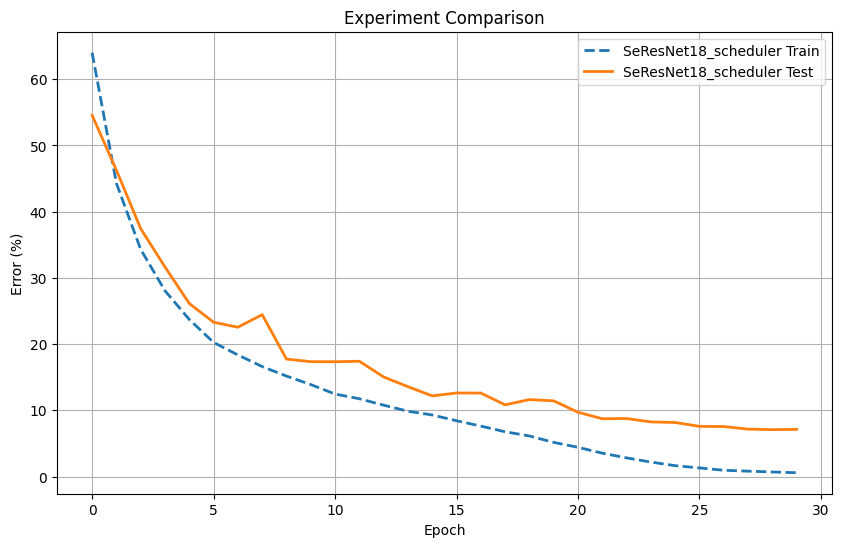

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

from models.SeResNetblock_dorpout import SEResNetDrop18 #模型加载

from utils.trainer_scheduler import train_model  #训练代码
from utils.plot import plot_experiment #绘图代码

import config


# =========================
# device
# =========================

device = config.DEVICE

print('device:', device)

transform_train = transforms.Compose([

    transforms.RandomCrop(32, padding=4), #对图像高宽进行填充 32*32->40*40

    transforms.RandomHorizontalFlip(), #对图像随机翻转

    transforms.ToTensor(),

    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),#CIFAR103通道均值
        (0.2023, 0.1994, 0.2010) #CIFAR103通道标准差
    )
])


transform_test = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

# =========================
# dataset
# =========================

train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=False,
    transform=transform_train
)


test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=False,
    transform=transform_test
)


# =========================
# dataloader
# =========================

train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=2
)


test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=2
)
# =========================
# loss
# =========================

criterion = nn.CrossEntropyLoss()



history = {}

# SEResNet18
model = SEResNetDrop18().to(device)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=config.LEARNING_RATE,
    momentum=config.MOMENTUM,
    weight_decay=config.WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config.EPOCHS
)

history['SeResNet18_scheduler'] = train_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    config.EPOCHS
)


plot_experiment(
    history,
    './outputs/figures/SEResNetDrop18_scheduler.png'
)



# SEResNetDrop18 sehodler shepoch100

device: cuda
>>> New Best Model! Acc=48.20%
Epoch [1/100] LR: 0.099975 BestAcc: 48.20% Loss: 1.6679 Train Error: 60.98% Test Error: 51.80%
>>> New Best Model! Acc=58.24%
Epoch [2/100] LR: 0.099901 BestAcc: 58.24% Loss: 1.1535 Train Error: 41.82% Test Error: 41.76%
>>> New Best Model! Acc=66.18%
Epoch [3/100] LR: 0.099778 BestAcc: 66.18% Loss: 0.8912 Train Error: 31.45% Test Error: 33.82%
>>> New Best Model! Acc=67.26%
Epoch [4/100] LR: 0.099606 BestAcc: 67.26% Loss: 0.7393 Train Error: 25.92% Test Error: 32.74%
>>> New Best Model! Acc=77.92%
Epoch [5/100] LR: 0.099384 BestAcc: 77.92% Loss: 0.6344 Train Error: 21.84% Test Error: 22.08%
>>> New Best Model! Acc=78.88%
Epoch [6/100] LR: 0.099114 BestAcc: 78.88% Loss: 0.5648 Train Error: 19.67% Test Error: 21.12%
Epoch [7/100] LR: 0.098796 BestAcc: 78.88% Loss: 0.5092 Train Error: 17.57% Test Error: 23.31%
>>> New Best Model! Acc=80.17%
Epoch [8/100] LR: 0.098429 BestAcc: 80.17% Loss: 0.4683 Train Error: 16.14% Test Error: 19.83%
Epoch [9/1

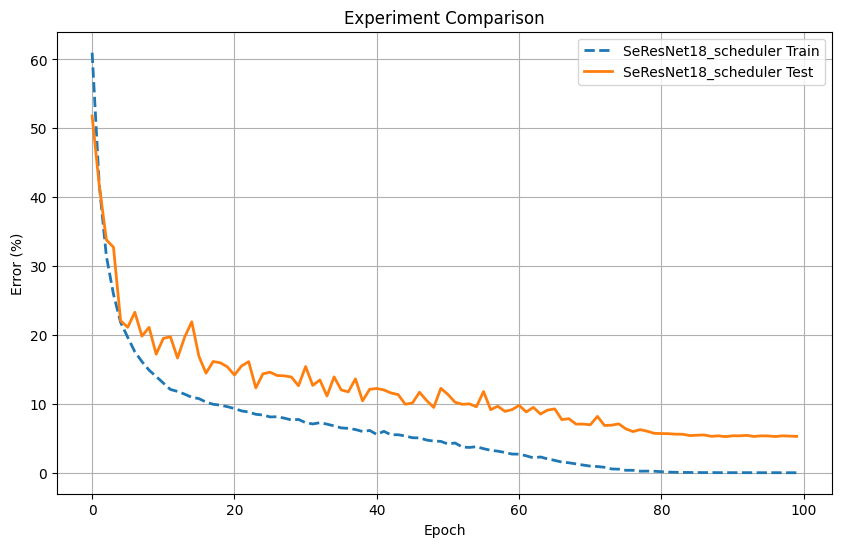

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

from models.SeResNetblock_dorpout import SEResNetDrop18 #模型加载

from utils.trainer_scheduler import train_model  #训练代码
from utils.plot import plot_experiment #绘图代码

import config


# =========================
# device
# =========================

device = config.DEVICE

print('device:', device)

transform_train = transforms.Compose([

    transforms.RandomCrop(32, padding=4), #对图像高宽进行填充 32*32->40*40

    transforms.RandomHorizontalFlip(), #对图像随机翻转

    transforms.ToTensor(),

    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),#CIFAR103通道均值
        (0.2023, 0.1994, 0.2010) #CIFAR103通道标准差
    )
])


transform_test = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

# =========================
# dataset
# =========================

train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=False,
    transform=transform_train
)


test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=False,
    transform=transform_test
)


# =========================
# dataloader
# =========================

train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=2
)


test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=2
)
# =========================
# loss
# =========================

criterion = nn.CrossEntropyLoss()



history = {}

# SEResNet18
model = SEResNetDrop18().to(device)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=config.LEARNING_RATE,
    momentum=config.MOMENTUM,
    weight_decay=config.WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config.EPOCHS
)

history['SeResNet18_scheduler'] = train_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    config.EPOCHS
)


plot_experiment(
    history,
    './outputs/figures/SEResNetDrop18_scheduler_epoch100.png'
)



# SEResNetDrop18 sehodler shepoch100 label_smoothing=0.1

device: cuda
>>> New Best Model! Acc=45.25%
Epoch [1/100] LR: 0.099975 BestAcc: 45.25% Loss: 1.7375 Train Error: 57.49% Test Error: 54.75%
>>> New Best Model! Acc=66.65%
Epoch [2/100] LR: 0.099901 BestAcc: 66.65% Loss: 1.3346 Train Error: 37.72% Test Error: 33.35%
>>> New Best Model! Acc=68.98%
Epoch [3/100] LR: 0.099778 BestAcc: 68.98% Loss: 1.1520 Train Error: 28.82% Test Error: 31.02%
>>> New Best Model! Acc=73.43%
Epoch [4/100] LR: 0.099606 BestAcc: 73.43% Loss: 1.0380 Train Error: 23.38% Test Error: 26.57%
>>> New Best Model! Acc=76.35%
Epoch [5/100] LR: 0.099384 BestAcc: 76.35% Loss: 0.9713 Train Error: 20.46% Test Error: 23.65%
Epoch [6/100] LR: 0.099114 BestAcc: 76.35% Loss: 0.9201 Train Error: 18.02% Test Error: 24.40%
>>> New Best Model! Acc=82.73%
Epoch [7/100] LR: 0.098796 BestAcc: 82.73% Loss: 0.8868 Train Error: 16.57% Test Error: 17.27%
>>> New Best Model! Acc=83.69%
Epoch [8/100] LR: 0.098429 BestAcc: 83.69% Loss: 0.8583 Train Error: 15.28% Test Error: 16.31%
Epoch [9/1

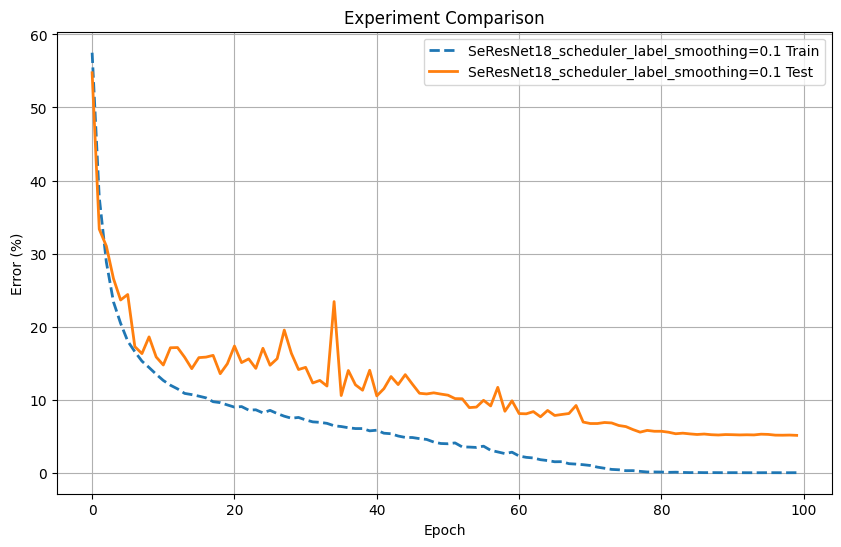

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

from models.SeResNetblock_dorpout import SEResNetDrop18 #模型加载

from utils.trainer_scheduler import train_model  #训练代码
from utils.plot import plot_experiment #绘图代码

import config


# =========================
# device
# =========================

device = config.DEVICE

print('device:', device)

transform_train = transforms.Compose([

    transforms.RandomCrop(32, padding=4), #对图像高宽进行填充 32*32->40*40

    transforms.RandomHorizontalFlip(), #对图像随机翻转

    transforms.ToTensor(),

    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),#CIFAR103通道均值
        (0.2023, 0.1994, 0.2010) #CIFAR103通道标准差
    )
])


transform_test = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

# =========================
# dataset
# =========================

train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=False,
    transform=transform_train
)


test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=False,
    transform=transform_test
)


# =========================
# dataloader
# =========================

train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=2
)


test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=2
)
# =========================
# loss
# =========================

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)



history = {}

# SEResNet18
model = SEResNetDrop18().to(device)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=config.LEARNING_RATE,
    momentum=config.MOMENTUM,
    weight_decay=config.WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config.EPOCHS
)

history['SeResNet18_scheduler_label_smoothing=0.1'] = train_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    config.EPOCHS
)


plot_experiment(
    history,
    './outputs/figures/SEResNetDrop18_scheduler_epoch100_label_smoothing=0.1.png'
)



# 有再验证深层Resnet网络更好

device: cuda
>>> New Best Model! Acc=39.95%
Epoch [1/100] Loss: 2.0388 BestAcc: 39.95% Train Error: 72.40% Test Error: 60.05%
>>> New Best Model! Acc=52.48%
Epoch [2/100] Loss: 1.4548 BestAcc: 52.48% Train Error: 53.78% Test Error: 47.52%
>>> New Best Model! Acc=57.27%
Epoch [3/100] Loss: 1.1771 BestAcc: 57.27% Train Error: 42.46% Test Error: 42.73%
>>> New Best Model! Acc=60.97%
Epoch [4/100] Loss: 0.9780 BestAcc: 60.97% Train Error: 34.86% Test Error: 39.03%
>>> New Best Model! Acc=72.32%
Epoch [5/100] Loss: 0.8358 BestAcc: 72.32% Train Error: 29.52% Test Error: 27.68%
>>> New Best Model! Acc=74.26%
Epoch [6/100] Loss: 0.7134 BestAcc: 74.26% Train Error: 25.16% Test Error: 25.74%
>>> New Best Model! Acc=77.46%
Epoch [7/100] Loss: 0.6194 BestAcc: 77.46% Train Error: 21.63% Test Error: 22.54%
>>> New Best Model! Acc=80.09%
Epoch [8/100] Loss: 0.5596 BestAcc: 80.09% Train Error: 19.49% Test Error: 19.91%
>>> New Best Model! Acc=80.14%
Epoch [9/100] Loss: 0.5138 BestAcc: 80.14% Train Err

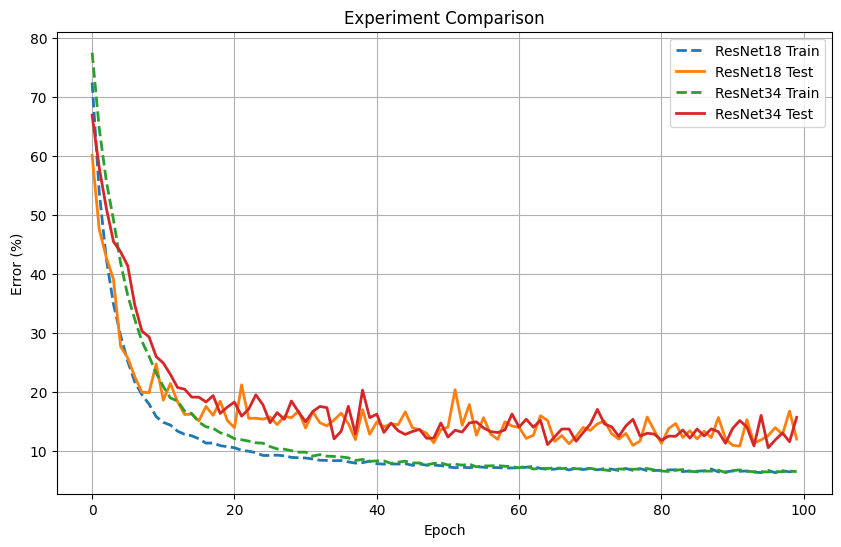

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

from models.resnet import ResNet18 #模型加载
from models.resnet import ResNet34

from utils.trainer import train_model  #训练代码
from utils.plot import plot_experiment #绘图代码

import config


# =========================
# device
# =========================

device = config.DEVICE

print('device:', device)

transform_train = transforms.Compose([

    transforms.RandomCrop(32, padding=4), #对图像高宽进行填充 32*32->40*40

    transforms.RandomHorizontalFlip(), #对图像随机翻转

    transforms.ToTensor(),

    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),#CIFAR103通道均值
        (0.2023, 0.1994, 0.2010) #CIFAR103通道标准差
    )
])


transform_test = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

# =========================
# dataset
# =========================

train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=False,
    transform=transform_train
)


test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=False,
    transform=transform_test
)


# =========================
# dataloader
# =========================

train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=2
)


test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=2
)
# =========================
# loss
# =========================

criterion = nn.CrossEntropyLoss()



history = {}

# ResNet18
model = ResNet18().to(device)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=config.LEARNING_RATE,
    momentum=config.MOMENTUM,
    weight_decay=config.WEIGHT_DECAY
)

history['ResNet18'] = train_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    device,
    config.EPOCHS
)

# ResNet34
model = ResNet34().to(device)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=config.LEARNING_RATE,
    momentum=config.MOMENTUM,
    weight_decay=config.WEIGHT_DECAY
)

history['ResNet34'] = train_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    device,
    config.EPOCHS
)

plot_experiment(
    history,
    './outputs/figures/resnet_compare_epoch.png'
)

